# Transfer Learning from Pre-trained Models
You also have fantastic access to different pre-trained models such as Xception, DenseNet, ResNest, VGG, and many other. For an updated key of available models see:
- https://keras.io/applications/

In [1]:
# # workaround for multiple OpenMP on Mac
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [1]:
%%time

# manipulated from Keras Documentation
#  https://keras.io/applications/
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

res_model = ResNet50(weights='imagenet')
res_model.summary()

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

CPU times: user 2.94 s, sys: 8.91 s, total: 11.9 s
Wall time: 3.68 s


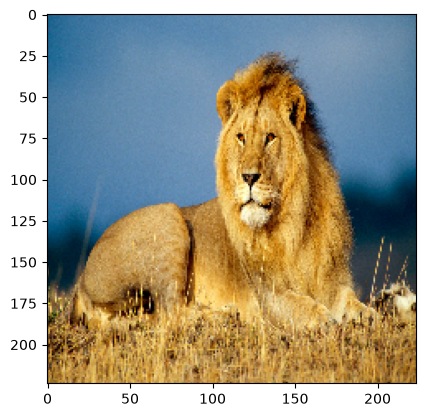

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline

def get_image(img_path):
    
    img = image.load_img(img_path, target_size=(224, 224))
    plt.imshow(image.img_to_array(img)/255)
    plt.grid(False)
    return image.img_to_array(img)

img_path = 'data/Simba.jpg'
x = get_image(img_path)

In [3]:

x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = res_model.predict(x)
# # decode the results into a list of tuples (class, description, probability)
print('Predicted:', decode_predictions(preds, top=3)[0])

2026-08-05 16:23:28.884095: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted: [('n02129165', 'lion', 0.99564725), ('n02130308', 'cheetah', 0.001323381), ('n07802026', 'hay', 0.0010097628)]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted: [('n04285008', 'sports_car', 0.8231059), ('n03100240', 'convertible', 0.075037725), ('n02974003', 'car_wheel', 0.06684465), ('n03459775', 'grille', 0.025561994), ('n04037443', 'racer', 0.004237333), ('n03770679', 'minivan', 0.0017386716), ('n02814533', 'beach_wagon', 0.0015378514), ('n04483307', 'trimaran', 0.0005192568), ('n03930630', 'pickup', 0.0003271222), ('n03670208', 'limousine', 0.0002570162)]


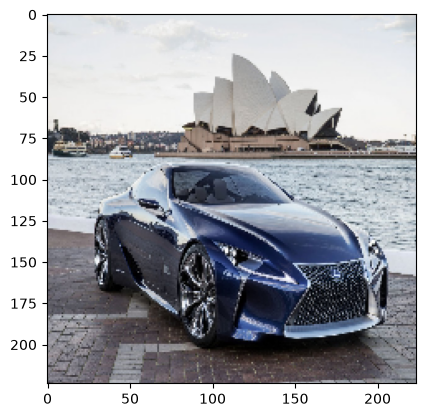

In [4]:
img_path = 'data/MyCar.jpg'
x = get_image(img_path)

x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = res_model.predict(x)
# decode the results into a list of tuples (class, description, probability)
print('Predicted:', decode_predictions(preds, top=10)[0])

In [5]:
# TODO: run on the tiny imagenet with model, to show performances

# Transfer Learning With ResNet
Let's do some learning based on the rock/paper/scissors dataset. In this example, I will use the tensorflow_datasets package for managing and dowloading the data.

In [6]:
import tensorflow_datasets as tfds

ds_train = tfds.load('rock_paper_scissors', split='train', shuffle_files=True)
ds_test = tfds.load('rock_paper_scissors', split='test', shuffle_files=False)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/eclarson/tensorflow_datasets/rock_paper_scissors/incomplete.MPHDKK_3.0.0/rock_paper_scissors-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/eclarson/tensorflow_datasets/rock_paper_scissors/incomplete.MPHDKK_3.0.0/rock_paper_scissors-…

Dataset rock_paper_scissors downloaded and prepared to /Users/eclarson/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


In [7]:
for element in ds_train.take(1):
    print(element['image'].shape)
    print(element['label'].numpy())

(300, 300, 3)
2


2026-08-05 16:23:41.571969: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


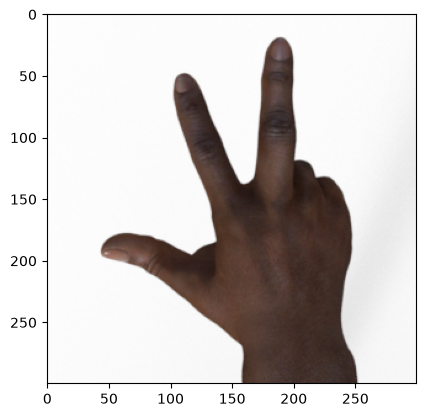

In [8]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.imshow(element['image'].numpy())
plt.grid(False)

In [9]:
# connect new layers to the output
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
import tensorflow as tf
import numpy as np

# load only convolutional layers of resnet:
if 'res_no_top' not in locals():
    res_no_top = ResNet50(weights='imagenet', include_top=False)

x = element['image'].numpy()
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

%time preds = res_no_top.predict(x)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
CPU times: user 692 ms, sys: 118 ms, total: 810 ms
Wall time: 1.25 s


(1, 10, 10, 2048)

In [10]:
x=preprocess_input(tf.expand_dims(element['image'], axis=0))
preds = res_no_top.predict(x)
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(1, 10, 10, 2048)

In [11]:
from tensorflow.keras.layers import SeparableConv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Input, Dense
from tensorflow.keras.models import Model

NUM_CLASSES = 3

# let's add a fully-connected layer
input_x = Input(shape=preds.shape[1:])

x = SeparableConv2D(filters=32,
               kernel_size=(3,3),
               #kernel_initializer='he_uniform', 
               padding='same', 
               activation='relu', 
               depth_multiplier = 1, # controls output channels
               data_format="channels_last")(input_x)

x = MaxPooling2D(pool_size=(2, 2), data_format="channels_last")(x)

x = Flatten()(x)
x = Dense(100, activation='relu',kernel_initializer='he_uniform')(x)
# and a fully connected layer 
predictions = Dense(NUM_CLASSES, activation='softmax', kernel_initializer='glorot_uniform')(x)

model = Model(inputs=input_x, outputs=predictions)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 10, 2048)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 10, 10, 32)     │        84,000 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        80,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,403 (642.20 KB)

 Trainable params: 164,403 (642.20 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.optimizers import Adam

# map the data such that we preprocess the data with the ResNet model

preprocessed_ds_train = ds_train.map(lambda element: (res_no_top(preprocess_input(tf.expand_dims(element['image'], axis=0))), element['label']), 
                                     num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


preprocessed_ds_test = ds_test.map(lambda element: (res_no_top(preprocess_input(tf.expand_dims(element['image'], axis=0))), element['label']), 
                                     num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)



In [13]:
%%time

opt = Adam() #default optimizer parameters
num_epochs = 5

# convert to tf tensor from Keras Variable for watch
trainable_variables_as_tf = [tmp.value for tmp in model.trainable_variables]

for e in range(num_epochs):
    # iterating over this is one full epoch
    for features, label in preprocessed_ds_train:
        # now the features and labels are for one batch
        with tf.GradientTape(watch_accessed_variables=False, persistent=False) as tape:
            # only watch the variables for this smaller model, to save time
            tape.watch(trainable_variables_as_tf)
            
            # run through the pre-trained processor
            #images = preprocess_input(element['image'])
            
            # and place through the pre-trained model
            #features = res_no_top(images)
            
            # put through the custom model
            yhat = model(features)
            
            # get the loss function
            # notice that the label is an integer, yhat is a vector
            # the 'sparse' keyword makes this the function expectation
            loss = sparse_categorical_crossentropy(tf.squeeze(label), tf.squeeze(yhat))
                        
        # update via auto diff and specified optimizer
        # only update the model head here
        grads = tape.gradient(loss, model.trainable_variables)
        opt.apply_gradients(zip(grads, model.trainable_variables))
        
    print(f'Finished epoch {e}')
       

2026-08-05 16:25:29.308390: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Finished epoch 0


2026-08-05 16:27:00.341949: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Finished epoch 1


2026-08-05 16:28:32.897283: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Finished epoch 2


2026-08-05 16:30:06.138285: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Finished epoch 3
Finished epoch 4
CPU times: user 49min 39s, sys: 13min 58s, total: 1h 3min 38s
Wall time: 7min 37s


2026-08-05 16:31:38.627623: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
num_points = 0
num_correct = 0

for features, label in preprocessed_ds_test:
    # run through the pre-trained processor
    #images = preprocess_input(element['image'])
    # and place through the pre-trained model
    #features = res_no_top(images)
    # put through the custom model
    yhat = model(features)

    # get the total batch number
    num_points += features.shape[0]

    # convert model output to an integer
    yhat = np.argmax(yhat.numpy(),axis=1)

    num_correct += sum([np.squeeze(yhat)==label.numpy()])
    
num_correct / num_points

2026-08-05 16:31:47.873043: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


0.9139784946236559